In [ ]:
import numpy as np
import networkx as ntwx
from scipy.linalg import sqrtm
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML as web
from networkx.algorithms.community.modularity_max import greedy_modularity_communities

%matplotlib inline

In [ ]:
def set_seed(seed=100):
    """sets seed"""
    np.random.seed(seed)

In [ ]:
def get_graph_metadata(graph, key=None):
    """Return metadata obout a graph i.e. number_of_nodes, number_of_edges and node attributes"""
    if key is None:
        return graph.number_of_nodes(), graph.number_of_edges()
    return graph.number_of_nodes(), graph.number_of_edges(), ntwx.get_node_attributes(graph, key)

def get_xavier_init(input_dim, output_dim):
    """returns xaviers in initializer"""
    std_dev = np.sqrt(5.0 / (input_dim + output_dim))
    return np.random.uniform(-std_dev, std_dev, size=(input_dim, output_dim))

def get_cross_entropy(pred, labels):
    """computes crossentropy between the predictions and the labels"""
    return -np.log(pred)[np.arange(pred.shape[0]), np.argmax(labels, axis=1)]


def normalized_difference_norm(dW, dW_approx):
    """compares the deirivarive of the weight with its apprimation"""
    return np.linalg.norm(dW - dW_approx) / (np.linalg.norm(dW) + np.linalg.norm(dW_approx))

def get_colors_labels_and_classes(graph, num_nodes):
    """We applied greedy modurality maximization from the original
    paper https://arxiv.org/pdf/1609.02907.pdf to come up with cluster
    labels for each of the members of the club. We will train our GNN
    to predict these cluster labels."""
    clusters = greedy_modularity_communities(graph)
    unsure_cluster = clusters[-1]
    clusters = clusters[:2]
    clusters[1] = clusters[1].union(unsure_cluster)
    color_lists = np.zeros(num_nodes)
    for i, cluster in enumerate(clusters):
        color_lists[list(cluster)] = i
    classes = np.unique(color_lists).shape[0]
    return color_lists, np.eye(classes)[color_lists.astype(int)], classes

def get_affiliation(club_labels):
    """return the affiation of the karate club members"""
    Mr_Hi, Officer = [], []
    for key, value in club_labels.items():
        if value == 'Mr. Hi':
            Mr_Hi.append(key)
        else:
            Officer.append(key)
    return Mr_Hi, Officer


def fill_diagonal(source_array, diagonal):
    """helps fill element of the source array into a diagonal matrix"""
    copy = source_array.copy()
    np.fill_diagonal(copy, diagonal)
    return copy


In [ ]:
def show_graph(graph,
               label_values_of_nodes,
               label_colors_of_nodes,
               colors_of_edges='black',
               display_window_size=15,
               positions_of_nodes=None,
               cmap='jet'):
    """helps visualize the graph"""
    fig, ax = plt.subplots(figsize=(display_window_size, display_window_size))
    if positions_of_nodes is None:
        # https://networkx.org/documentation/stable/reference/generated/networkx.drawing.layout.spring_layout.html
        positions_of_nodes = ntwx.spring_layout(graph,
                                                k=5/np.sqrt(graph.number_of_nodes()))
        # https://networkx.org/documentation/stable/reference/drawing.html
    ntwx.draw(
        graph,
        positions_of_nodes,
        with_labels=label_values_of_nodes,
        labels=label_values_of_nodes,
        node_color=label_colors_of_nodes,
        ax=ax,
    cmap=cmap,
    edge_color=colors_of_edges)


def plot_training_curves(train_losses, test_losses, accs, grid=False):
    """shows training curves"""
    fig = plt.figure(figsize=(10, 4))
    ax1 = fig.add_subplot(121)
    ax1.plot(np.log10(train_losses), label='train')
    ax1.plot(np.log10(test_losses), label='test')
    ax1.legend()
    if grid:
        ax1.grid()

    ax2 = fig.add_subplot(122)
    ax2.plot(accs, label='acc')
    ax2.set(ylim=[0,1])
    ax2.legend()

    if grid:
        ax2.grid()

In [ ]:

def compute_gradients(param_name, layer, inputs_data, gt_labels, eps=1e-4, weight_decay=0):
    """Compute the gradient with respect to a a given parameter in a given layer"""
    gradients_utils = {}
    batch_size = gt_labels.shape[0]
    replica = getattr(layer, param_name).copy()
    replica_flattened = np.asarray(replica).flatten()
    gradients_utils['gradient_values'] = np.zeros(replica_flattened.shape)
    n_parms = replica_flattened.shape[0]
    for ind, param in enumerate(replica_flattened):
        # lower bound cost
        replica_flattened[ind] = param - eps
        temp = replica_flattened.reshape(replica.shape)
        gradients_utils['lower_bound_pred'] = layer.forward_pass(*inputs_data, **{param_name: temp})
        decay = weight_decay/ 2 * np.sum(replica_flattened ** 2) / batch_size
        lower_cost = np.mean(get_cross_entropy(gradients_utils['lower_bound_pred'],
                                               gt_labels)) + decay
        # upper bound cost
        replica_flattened[ind] = param + eps
        temp = replica_flattened.reshape(replica.shape)
        gradients_utils['upper_bound_pred'] = layer.forward_pass(*inputs_data, **{param_name: temp})
        decay = weight_decay/ 2 * np.sum(replica_flattened**2) / batch_size

        upper_cost = np.mean(get_cross_entropy(gradients_utils['upper_bound_pred'],
                                               gt_labels)) + decay
        gradients_utils['gradient_values'][ind] = ((upper_cost - lower_cost) / (2 * eps))
        replica_flattened[ind] = param
    return gradients_utils['gradient_values'].reshape(replica.shape)

In [ ]:
class Grad_Descent_Optimizer():
    """Performs Gradient Descent"""
    def __init__(self, learning_rate, weight_decay):
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self._y_pred = None
        self._y_true = None
        self._output = None
        self.batch_size = None
        self.nodes_to_be_trained = None

    def __call__(self, y_pred, y_true, nodes_to_be_used_for_training=None):
        self.y_pred = y_pred
        self.y_true = y_true
        self.batch_size = y_pred.shape[0]

        if nodes_to_be_used_for_training is None:
            self.nodes_to_be_used_for_training = np.arange(self.batch_size)
        else:
            self.nodes_to_be_used_for_training = nodes_to_be_used_for_training

    @property
    def out(self, ):
        return self._output

    @out.setter
    def out(self, y):
        self._output = y

In [ ]:
set_seed()

In [ ]:
def implementation_check(dW, dW_approx, db, db_approx):
    """This function helps check how correct in your impplementation a layer"""
    try:
        assert normalized_difference_norm(dW, dW_approx) < 1e-7
        assert normalized_difference_norm(db, db_approx) < 1e-7
        print('congrats, your implementation passes the test !!!')
    except:
        print('Not quite there :( yet; your implementation did not pass the test')

In [ ]:
def train_test_split(test_nodes, labels):
    return np.array([i for i in range(labels.shape[0]) if i not in test_nodes])

def threshold(arr, threshold_value=0.5):
    """This function treshold the output of a softmax to either be 0 or 1"""
    arr[arr>=threshold_value]=1
    arr[arr<threshold_value]=0
    return arr

In [ ]:
class Softmax_Layer():
    """applies a weight multiplication and returns the forward and backward passes softmax. Some values are cached
    so we could use them to compute the gredients.
    Returns: (batch_size, output_dim)"""
    def __init__(self, input_dim, output_dim, name=''):
        self.name = name
        self.cache = {}
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.bias = np.zeros((self.output_dim, 1))
        self.W = get_xavier_init(self.output_dim, self.input_dim)

    def __repr__(self):
        dims = (self.input_dim, self.output_dim)
        if self.name:
            return f"Softmax_Layer: W{'_' + self.name}{dims}"
        else:
            return f"Softmax_Layer: W{'_'+ ''}{dims}"

    def get_softmax(self, x):
        x = x - np.max(x, axis=0, keepdims=True)
        exp_x = np.exp(x)
        return exp_x / np.sum(exp_x, axis=0, keepdims=True)

    def forward_pass(self, X, W=None, bias=None):
        """Returns the softmax of the input X after appliying the weight and biases."""
        self.cache['X'] = X.T
        if W is None:
            W = self.W
        if bias is None:
            bias = self.bias

        return self.get_softmax(np.asarray(W @ self.cache['X']) + bias).T # (batch_size, output_dim)

    def backward_pass(self, optimizer, need_update=True):
        """mask nodes nodes not revelant for training, and updates optimizer parameters"""
        training_mask = np.zeros(optimizer.y_pred.shape[0])
        training_mask[optimizer.nodes_to_be_trained] = 1
        training_mask = training_mask.reshape((-1, 1))

        dLoss = np.asarray((optimizer.y_pred - optimizer.y_true))
        dLoss = np.multiply(dLoss, training_mask)

        self.grad = dLoss @ self.W # (batch_size, input_dim)
        optimizer.output = self.grad

        dW = (dLoss.T @ self.cache['X'].T) / optimizer.batch_size # (output_dim, input_dim)
        dbias = np.sum(dLoss.T, axis=1, keepdims=True) / optimizer.batch_size # (output_dim, 1)

        dW_weight_decay = self.W * optimizer.weight_decay / optimizer.batch_size

        if need_update:
            self.W = self.W - (dW + dW_weight_decay) * optimizer.learning_rate
            self.bias = self.bias - dbias.reshape(self.bias.shape) * optimizer.learning_rate

        return dW + dW_weight_decay, dbias.reshape(self.bias.shape)

In [ ]:
graph = ntwx.karate_club_graph()
num_nodes, num_edges, club_labels = get_graph_metadata(graph, 'club')
colors, labels, num_classes = get_colors_labels_and_classes(graph, num_nodes)
Mr_Hi_people, Officer_people = get_affiliation(club_labels)

ZKC dataset graph has 34 nodes and 78 edges
The affiation of each of the 34 members between the officer and Mr. Hi is given below:
 {0: 'Mr. Hi', 1: 'Mr. Hi', 2: 'Mr. Hi', 3: 'Mr. Hi', 4: 'Mr. Hi', 5: 'Mr. Hi', 6: 'Mr. Hi', 7: 'Mr. Hi', 8: 'Mr. Hi', 9: 'Officer', 10: 'Mr. Hi', 11: 'Mr. Hi', 12: 'Mr. Hi', 13: 'Mr. Hi', 14: 'Officer', 15: 'Officer', 16: 'Mr. Hi', 17: 'Mr. Hi', 18: 'Officer', 19: 'Mr. Hi', 20: 'Officer', 21: 'Mr. Hi', 22: 'Officer', 23: 'Officer', 24: 'Officer', 25: 'Officer', 26: 'Officer', 27: 'Officer', 28: 'Officer', 29: 'Officer', 30: 'Officer', 31: 'Officer', 32: 'Officer', 33: 'Officer'}
nodes/people loyal to Mr. Hi are:
 [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 16, 17, 19, 21]
nodes/people loyal to the officer are:
 [9, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]


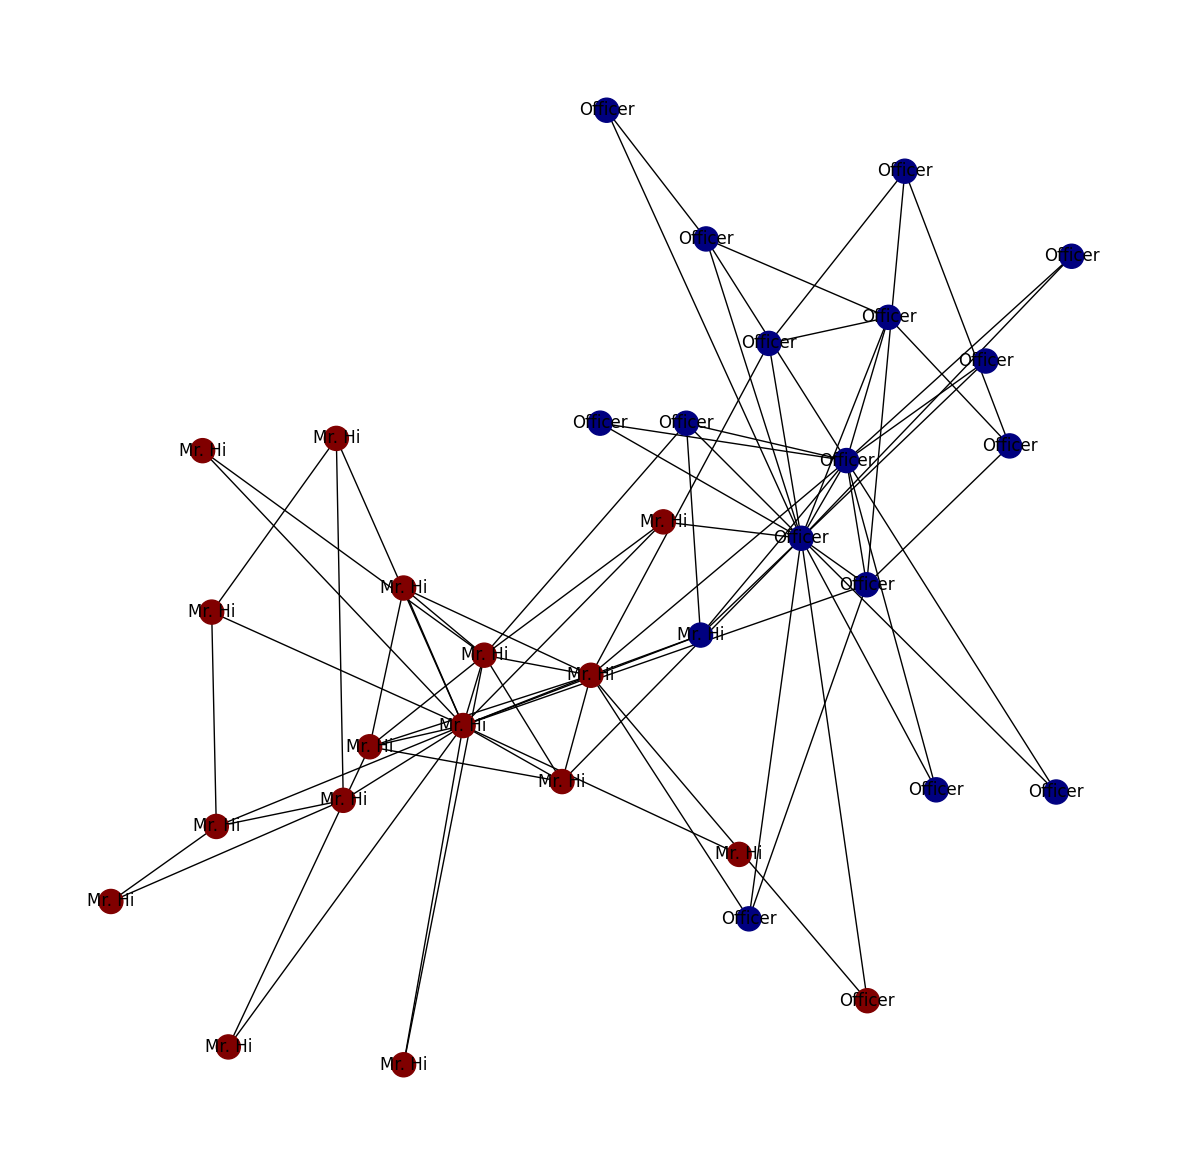

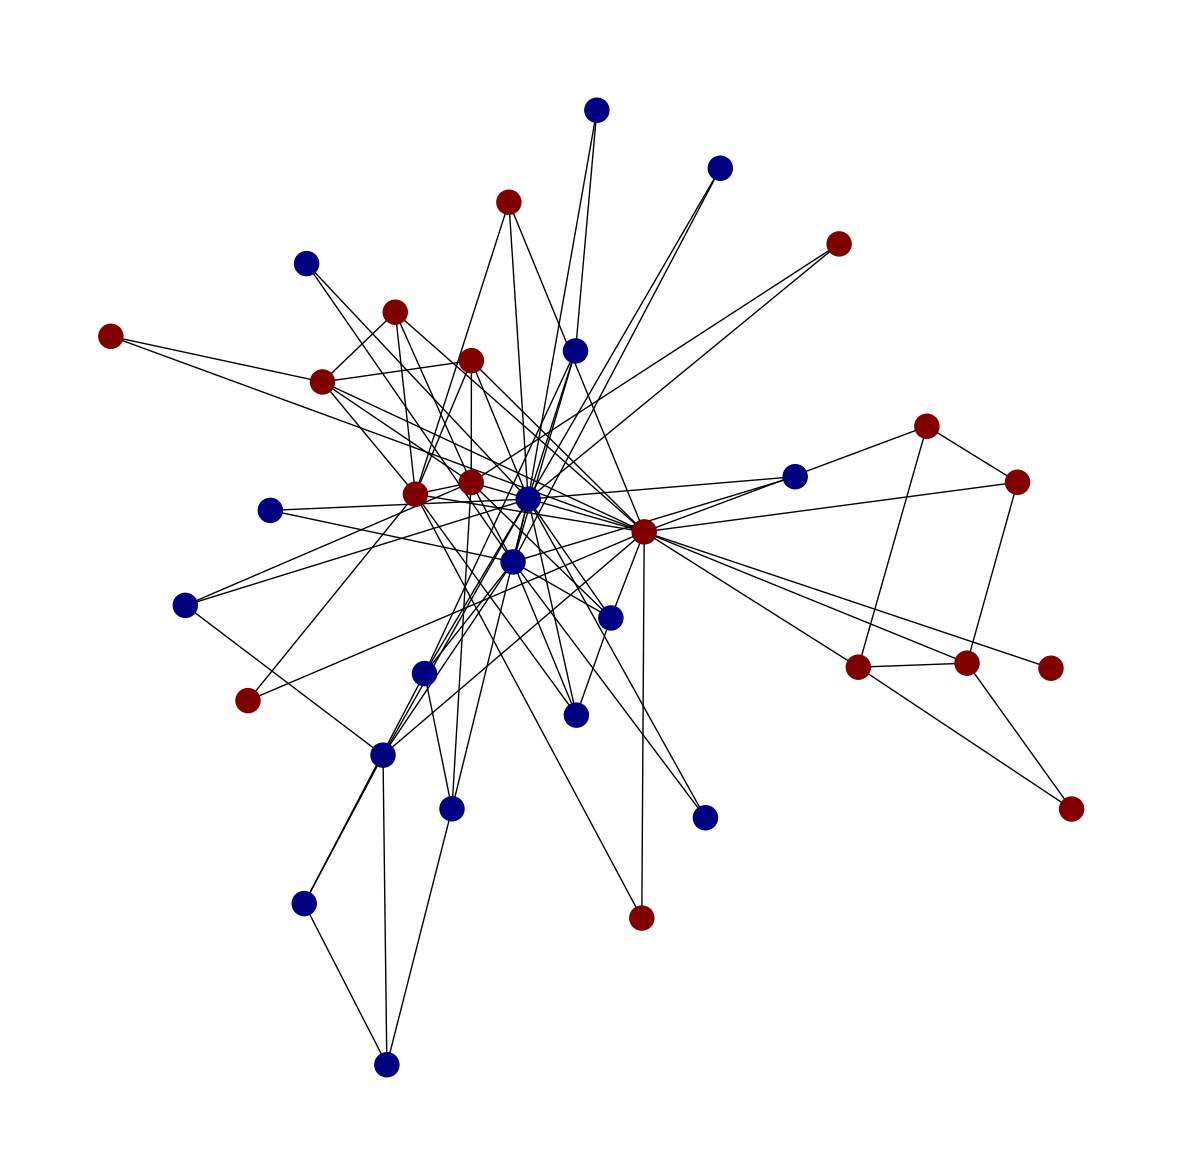

In [ ]:
print(f'ZKC dataset graph has {num_nodes} nodes and {num_edges} edges')
print(f'The affiation of each of the 34 members between the officer and Mr. Hi is given below:\n {club_labels}')
print(f'nodes/people loyal to Mr. Hi are:\n {Mr_Hi_people}')
print(f'nodes/people loyal to the officer are:\n {Officer_people}')
assert len(Officer_people) + len(Mr_Hi_people) == num_nodes
show_graph(graph=graph,
           label_values_of_nodes=club_labels,
           label_colors_of_nodes=colors,
           colors_of_edges='black',
           positions_of_nodes=None)
show_graph(graph=graph,
           label_values_of_nodes=None,
           label_colors_of_nodes=colors,
           colors_of_edges='black',
           positions_of_nodes=None,)

In [ ]:
A = ntwx.to_numpy_array(graph)
A

array([[0., 4., 5., ..., 2., 0., 0.],
       [4., 0., 6., ..., 0., 0., 0.],
       [5., 6., 0., ..., 0., 2., 0.],
       ...,
       [2., 0., 0., ..., 0., 4., 4.],
       [0., 0., 2., ..., 4., 0., 5.],
       [0., 0., 0., ..., 4., 5., 0.]])

Q1

In [ ]:
A_tild = A + np.eye(num_nodes)


Q2

In [ ]:
def get_adjacency_matrix(A_tild):
    D = np.sum(A_tild, axis=1)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(D))
    A_hat = D_inv_sqrt @ A_tild @ D_inv_sqrt
    return A_hat


In [ ]:
A_hat = get_adjacency_matrix(A_tild)
A_hat

array([[0.02325581, 0.11136921, 0.13076645, ..., 0.06502561, 0.        ,
        0.        ],
       [0.11136921, 0.03333333, 0.18786729, ..., 0.        , 0.        ,
        0.        ],
       [0.13076645, 0.18786729, 0.02941176, ..., 0.        , 0.0549235 ,
        0.        ],
       ...,
       [0.06502561, 0.        , 0.        , ..., 0.04545455, 0.13655775,
        0.12182898],
       [0.        , 0.        , 0.0549235 , ..., 0.13655775, 0.02564103,
        0.11437725],
       [0.        , 0.        , 0.        , ..., 0.12182898, 0.11437725,
        0.02040816]])

Q3

In [ ]:
X = np.eye(num_nodes)


In [ ]:
Q4

In [ ]:
class GNN_Layer():
    def __init__(self, input_dim, output_dim, name=''):
        self.name = name
        self.cache = {}
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.W = get_xavier_init(self.output_dim, self.input_dim)
        self.activation = np.tanh

    def __repr__(self):
        dims = (self.input_dim, self.output_dim)
        return f"GNN_Layer: W_{self.name}{dims}"

    def forward_pass(self, A, X, W=None):
        self.cache['A'] = A
        self.cache['X'] = X
        if W is None:
            W = self.W
        H = A @ X @ W.T
        H = self.activation(H)
        self.cache['H'] = H
        return H

    def backward_pass(self, optimizer, need_update=True):
        dtanh = 1 - np.power(self.cache['H'], 2)
        d = np.multiply(optimizer.output, dtanh)

        self.grad = self.cache['A'] @ d @ self.W
        optimizer.output = self.grad

        dW = (d.T @ self.cache['A'] @ self.cache['X']) / optimizer.batch_size
        dW_weight_decay = self.W * optimizer.weight_decay / optimizer.batch_size

        if need_update:
            self.W -= (dW + dW_weight_decay) * optimizer.learning_rate

        return dW + dW_weight_decay


In [ ]:
gnn_layer = GNN_Layer(input_dim=num_nodes,
                output_dim=2,
                name='gnn_layer_1')

sm_layer = Softmax_Layer(input_dim=2,
                   output_dim=num_classes,
                   name='softmax_layer')

optim = Grad_Descent_Optimizer(learning_rate=0,
                               weight_decay=1.)

Q5

In [ ]:
gnn_layer_output = gnn_layer.forward_pass(A=A_hat, X=X)
optim(y_pred=sm_layer.forward_pass(X=gnn_layer_output), y_true=labels)


In [ ]:
dW_approx = compute_gradients(param_name="W",
                              layer=sm_layer,
                              inputs_data=(gnn_layer_output,),
                              gt_labels=labels,
                              eps=1e-4,
                              weight_decay=optim.weight_decay)

db_approx = compute_gradients(param_name="bias",
                              layer=sm_layer,
                              inputs_data=(gnn_layer_output,),
                              gt_labels=labels,
                              eps=1e-4,
                              weight_decay=optim.weight_decay)

In [ ]:
dW, db = sm_layer.backward_pass(optim, need_update=False)

In [ ]:
dW, db = sm_layer.backward_pass(optim, need_update=False)

In [ ]:
implementation_check(dW, dW_approx, db, db_approx)

congrats, your implementation passes the test !!!


Q6

In [ ]:
class GNN():
    def __init__(self, input_dim, output_dim, hidden_dim, num_layers):
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.layers = []

        self.layers.append(GNN_Layer(input_dim, hidden_dim[0], name='layer_0'))
        for i in range(1, num_layers):
            self.layers.append(GNN_Layer(hidden_dim[i - 1], hidden_dim[i], name=f'layer_{i}'))
        self.layers.append(Softmax_Layer(input_dim=hidden_dim[-1],
                                         output_dim=output_dim,
                                         name='sm_layer'))

    def __repr__(self):
        return '\n'.join([str(layer) for layer in self.layers])

    def embedding(self, A, X):
        H = X
        for layer in self.layers[:-1]:
            H = layer.forward_pass(A, H)
        return H

    def forward_pass(self, A, X):
        H = self.embedding(A, X)
        return self.layers[-1].forward_pass(H)


In [ ]:
gnn_model = GNN(input_dim=num_nodes,
                output_dim=num_classes,
                num_layers=2,
                hidden_dim=[16, 2])


In [ ]:
test_nodes = np.array([0, 1, 8, 3, 8, 15, 16, 20, 25, 28, 30])
train_nodes = train_test_split(test_nodes, labels)

In [ ]:
print(f'The nodes that will be used for training are:\n {train_nodes}')

The nodes that will be used for training are:
 [ 2  4  5  6  7  9 10 11 12 13 14 17 18 19 21 22 23 24 26 27 29 31 32 33]


In [ ]:
print(f'The nodes that will be used for test/val are:\n {test_nodes}')

The nodes that will be used for test/val are:
 [ 0  1  8  3  8 15 16 20 25 28 30]


In [ ]:
training_optim = Grad_Descent_Optimizer(learning_rate=2e-2, weight_decay=2.5e-2)

Q8

In [ ]:
def train(model, A_hat, X, y_true, nodes_to_be_used_for_training, nodes_to_be_used_for_testing,
          threshold_value=0.5, ealy_stopping_steps=60, num_epochs=20000):

    accs = []
    training_losses = []
    testing_losses = []
    embeddings = []
    y_preds = []

    minimum_loss = 1e7
    ealy_stopping_counter = 0

    for epoch in range(num_epochs):
        y_pred = model.forward_pass(A_hat, X)
        training_optim(y_pred, y_true, nodes_to_be_used_for_training)

        for layer in reversed(model.layers):
            layer.backward_pass(training_optim, need_update=True)

        embeddings.append(model.embedding(A_hat, X))
        y_preds.append(y_pred)

        acc_temp = (np.argmax(y_pred, axis=1) == np.argmax(y_true, axis=1))[nodes_to_be_used_for_testing]
        accs.append(np.mean(acc_temp))

        loss_temp = get_cross_entropy(y_pred, y_true)
        train_loss_temp = np.mean(loss_temp[nodes_to_be_used_for_training])
        test_loss_temp = np.mean(loss_temp[nodes_to_be_used_for_testing])

        training_losses.append(train_loss_temp)
        testing_losses.append(test_loss_temp)

        if test_loss_temp < minimum_loss:
            minimum_loss = test_loss_temp
            ealy_stopping_counter = 0
        else:
            ealy_stopping_counter += 1

        if ealy_stopping_counter > ealy_stopping_steps:
            print("Training Stopped due to Early stopping!")
            break

        if epoch % 100 == 0:
            print(f"epoch #: {epoch + 1} | train Loss: {train_loss_temp:.3f} | test Loss: {test_loss_temp:.3f}")

    training_losses = np.array(training_losses)
    testing_losses = np.array(testing_losses)
    y_preds = threshold(np.array(y_preds), threshold_value)
    return training_losses, testing_losses, accs, embeddings, y_preds


In [ ]:
training_losses, testing_losses, accs, embeddings, preds = train(model=gnn_model,
                                  A_hat=A_hat,
                                  X=X,
                                  y_true=labels,
                                  nodes_to_be_used_for_training=train_nodes,
                                  nodes_to_be_used_for_testing=test_nodes,
                                  ealy_stopping_steps=50,
                                  num_epochs=20000)

epoch #: 1 | train Loss: 0.691 | test Loss: 0.691
epoch #: 101 | train Loss: 0.689 | test Loss: 0.688
epoch #: 201 | train Loss: 0.686 | test Loss: 0.685
epoch #: 301 | train Loss: 0.681 | test Loss: 0.680
epoch #: 401 | train Loss: 0.673 | test Loss: 0.672
epoch #: 501 | train Loss: 0.660 | test Loss: 0.659
epoch #: 601 | train Loss: 0.638 | test Loss: 0.638
epoch #: 701 | train Loss: 0.601 | test Loss: 0.602
epoch #: 801 | train Loss: 0.541 | test Loss: 0.544
epoch #: 901 | train Loss: 0.457 | test Loss: 0.463
epoch #: 1001 | train Loss: 0.361 | test Loss: 0.370
epoch #: 1101 | train Loss: 0.276 | test Loss: 0.285
epoch #: 1201 | train Loss: 0.214 | test Loss: 0.222
epoch #: 1301 | train Loss: 0.173 | test Loss: 0.178
epoch #: 1401 | train Loss: 0.145 | test Loss: 0.148
epoch #: 1501 | train Loss: 0.127 | test Loss: 0.127
epoch #: 1601 | train Loss: 0.115 | test Loss: 0.112
epoch #: 1701 | train Loss: 0.105 | test Loss: 0.101
epoch #: 1801 | train Loss: 0.098 | test Loss: 0.093
epoch

In [ ]:
print(f'For this toy example, the classification accuracy on the test set is {accs[-1]}')

For this toy example, the classification accuracy on the test set is 1.0


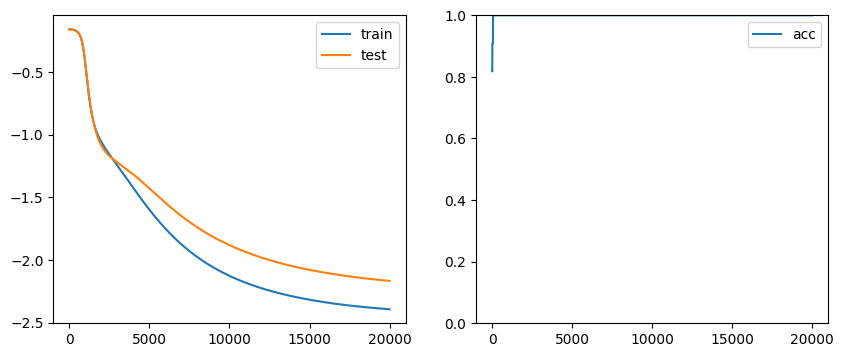

In [ ]:
plot_training_curves(training_losses, testing_losses, accs)

In [ ]:
[club_labels[i] for i in test_nodes]

['Mr. Hi',
 'Mr. Hi',
 'Mr. Hi',
 'Mr. Hi',
 'Mr. Hi',
 'Officer',
 'Mr. Hi',
 'Officer',
 'Officer',
 'Officer',
 'Officer']

In [ ]:
embeddings[-1][test_nodes]

array([[-0.95209592, -0.8307538 ],
       [-0.88392354, -0.70495313],
       [ 0.55379331,  0.41417394],
       [-0.90970714, -0.75512096],
       [ 0.55379331,  0.41417394],
       [ 0.81936195,  0.64904475],
       [-0.8030042 , -0.61935912],
       [ 0.83554654,  0.66811579],
       [ 0.97745028,  0.89500138],
       [ 0.5442372 ,  0.38729535],
       [ 0.67294235,  0.50840521]])

In [ ]:
labels[test_nodes]

array([[0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.]])

In [ ]:
preds[-1][test_nodes]

array([[0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.]])

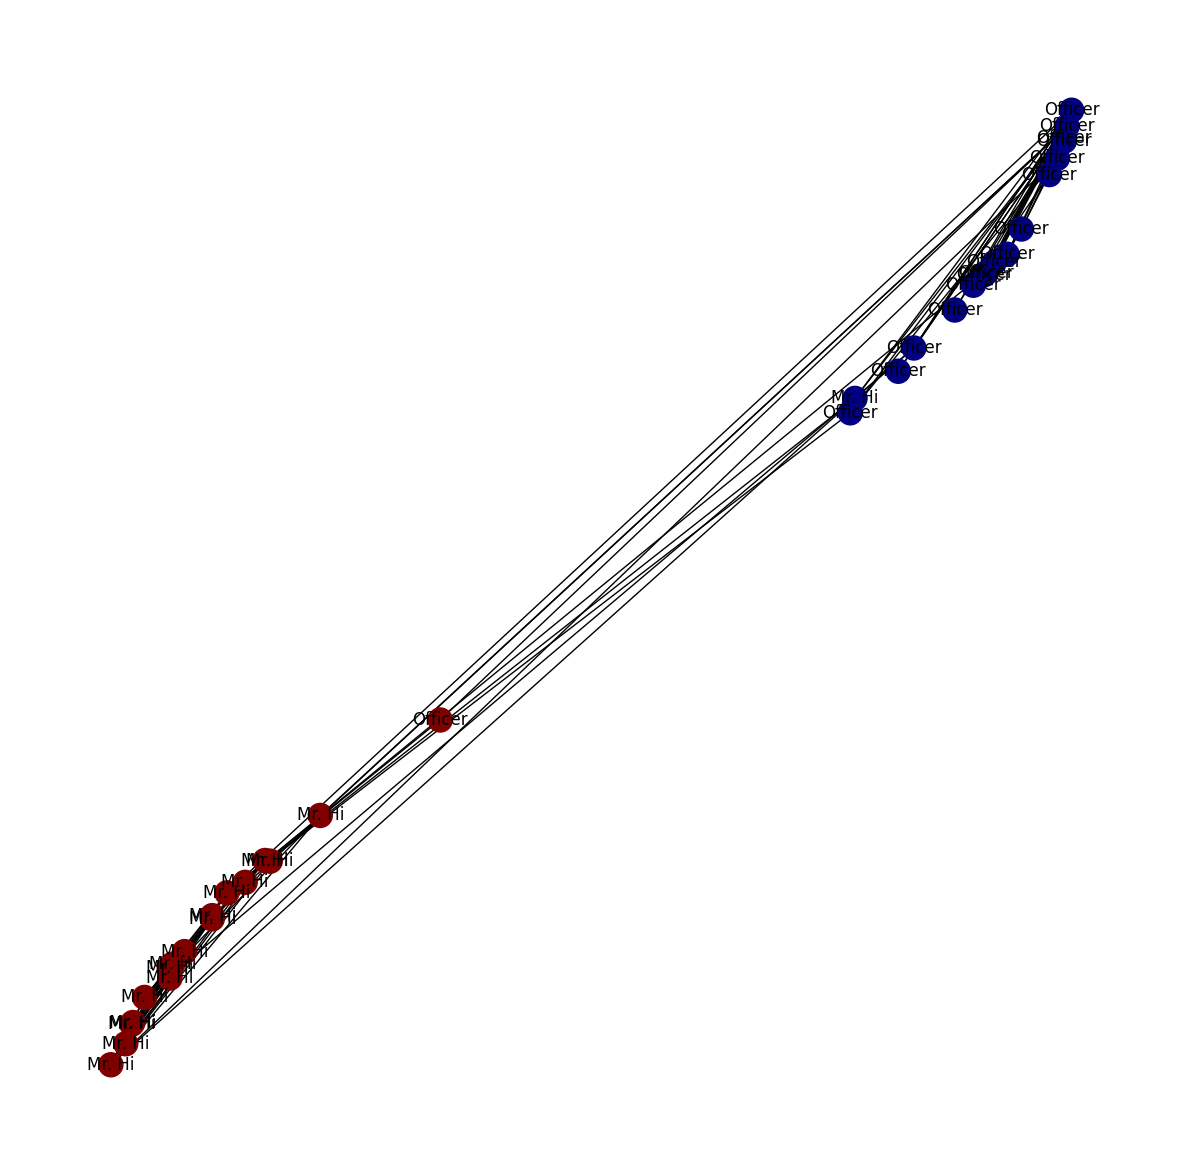

In [ ]:
show_graph(graph=graph,
           label_values_of_nodes=club_labels,
           label_colors_of_nodes=colors,
           colors_of_edges='black',
           positions_of_nodes={i: embeddings[-1][i,:] \
                               for i in range(embeddings[-1].shape[0])},
          )

Q9
Although the test accuracy is 100%, some embeddings appear misclassified in the plot as accuracy is based on argmax class predictions, not embedding positions. A node’s embedding may lie closer to the wrong cluster visually but still be classified correctly by the softmax layer. Therfore, visual mismatch can occur even when predictions are correct.